# Buy a machine outright, or borrow to buy it

A workshop needs a CNC mill. It can pay the whole price today, or put down a
deposit and borrow the rest over five years. Both machines run the same hours
and cost the same to feed, so the question is purely one of financing.

The appraisal runs over eight years on a monthly grid at a 5% discount rate.

In [1]:
from dataclasses import dataclass
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

from simplyinvest import Amount, Term, Timeline, compare
from simplyinvest.appraisal import Alternative
from simplyinvest.cashflow import CashFlowSeries, Component, Explicit, Role
from simplyinvest.domain import ConstantAnnualUsage, Context, GeometricDecline
from simplyinvest.financing import AnnuityLoan, CashPurchase

plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.5),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

MONEY = FuncFormatter(lambda value, _: f"{value:,.0f}")
PAID = "#2b6cb0"
BORROWED = "#c05621"

## The model

The package knows nothing about mills. A domain supplies two things: an asset,
which is anything with a price and a resale value, and a flow source, which is
anything that produces cash flows over the grid.

In [2]:
@dataclass(frozen=True)
class Machine:
    """A capital asset that loses value with age."""

    name: str
    price: float
    consumables_per_hour: float
    decline: float = 0.18
    age_at_acquisition: Term = Term.ZERO
    economic_life: Term | None = None

    @property
    def capital_cost(self) -> Amount:
        return Amount.paid(self.price)

    @property
    def setup_cost(self) -> Amount:
        return Amount.paid(2_400.0)

    def residual_value(self, *, held: Term) -> Amount:
        return Amount.received(
            GeometricDecline(self.decline).value_after(
                self.price, held=held, age_at_acquisition=self.age_at_acquisition
            )
        )


@dataclass(frozen=True)
class Running:
    """Consumables, priced per machine-hour and escalating with the grid."""

    machine: Machine
    supports_batch: bool = True

    def flows(self, ctx: Context) -> CashFlowSeries:
        hours = ctx.usage.per_period("hours", ctx.timeline)
        return CashFlowSeries.of(
            Explicit(
                -hours * self.machine.consumables_per_hour,
                label=Component(Role.OPERATING, "consumables"),
                description="Consumables",
            )
        )

    def constraints(self, ctx: Context) -> tuple[str, ...]:
        return ()

## The two alternatives

Nothing here says "car" or "machine" to the engine. An `Alternative` is a name,
some flow sources, a tax treatment and a life — four fields, no domain word.

In [3]:
machine = Machine("CNC mill", price=86_000.0, consumables_per_hour=4.20)

timeline = Timeline(
    Term.of_years(8),
    periods_per_year=12,
    rate=0.05,
    start_date=date(2026, 4, 1),
    escalations={"consumables": 0.02},
)
usage = ConstantAnnualUsage({"hours": 1_600})

loan = AnnuityLoan(rate=0.065, term=Term.of_years(5), down_payment=15_000)

cash = Alternative(
    "Pay cash",
    sources=(CashPurchase().bind(machine), Running(machine)),
    life=Term.of_years(8),
)
credit = Alternative(
    "Borrow at 6.5%",
    sources=(loan.bind(machine), Running(machine)),
    life=Term.of_years(8),
)

result = compare([cash, credit], timeline, usage=usage)
display(Markdown(result.to_markdown()))

| Alternative | Net present value | Equivalent annual cost | Payback |
| --- | ---: | ---: | ---: |
| Pay cash | -120,920.78 | 20,491.41 | — |
| Borrow at 6.5% | -123,405.96 | 20,875.92 | — |

Pay cash is better than Borrow at 6.5% by 2,485.18 in present value.

**Obligations these figures do not price:**

- Borrow at 6.5%: Borrowing at 6.50% against a discount rate of 5.00%: the loan destroys value relative to paying cash.

## Where the money goes

Every present value decomposes into labelled components that provably sum back
to the total. The deposit and the instalments are separate components, so the
cost of the credit is visible rather than buried in the price.

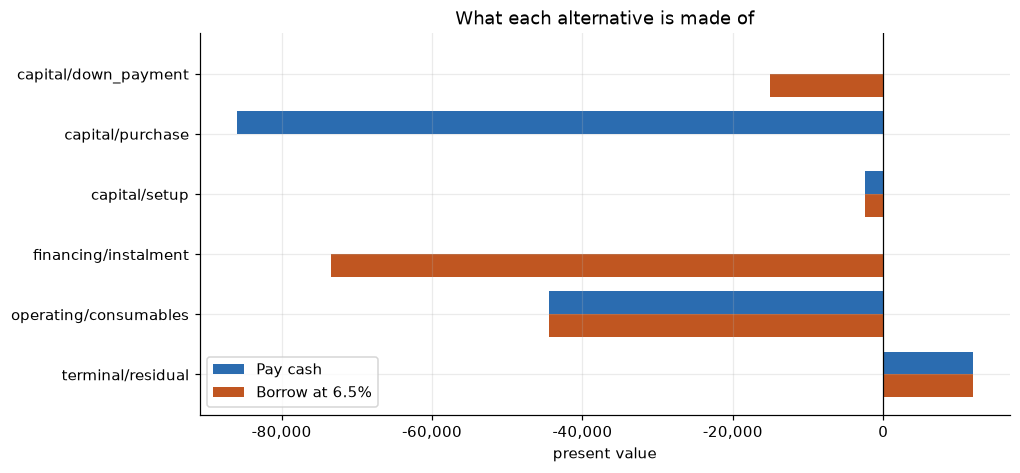

In [4]:
names = result.names
by_name = {
    a.name: {str(label): float(value) for label, value in a.breakdown().items()} for a in result
}
components = sorted({label for parts in by_name.values() for label in parts})
heights = np.array([[by_name[name].get(label, 0.0) for label in components] for name in names])

fig, ax = plt.subplots()
rows = np.arange(len(components))
width = 0.38
for index, (name, colour) in enumerate(zip(names, (PAID, BORROWED), strict=True)):
    ax.barh(rows + (index - 0.5) * width, heights[index], height=width, label=name, color=colour)

ax.set_yticks(rows, components)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(MONEY)
ax.set_xlabel("present value")
ax.set_title("What each alternative is made of")
ax.legend(loc="lower left")
ax.invert_yaxis()
plt.show()

## How the gap opens up

Discounted cash flow, accumulated period by period. Paying cash is worse for the
first four years — the whole price leaves on day one — and the lines cross only
once the instalments have run long enough to overtake it.

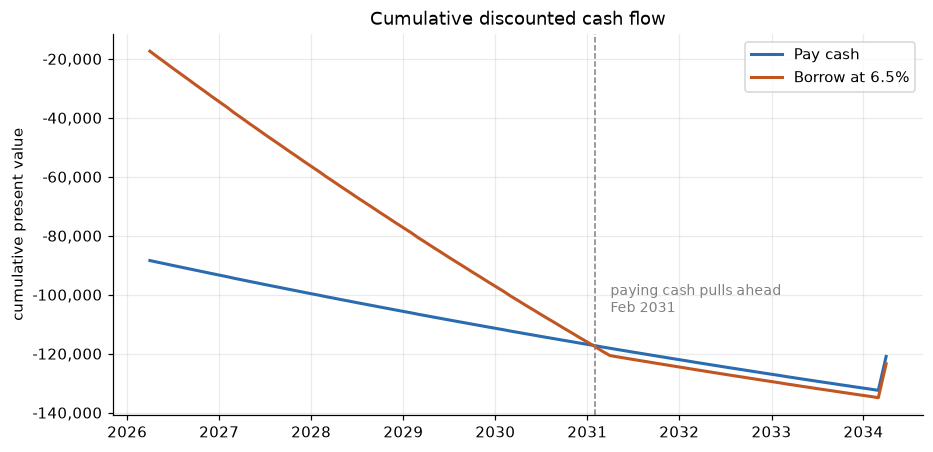

In [5]:
dates = np.array(timeline.dates())
factors = timeline.discount_factors()
cumulative = {name: np.cumsum(result[name].amounts * factors) for name in names}

fig, ax = plt.subplots()
for name, colour in zip(names, (PAID, BORROWED), strict=True):
    ax.plot(dates, cumulative[name], label=name, color=colour, linewidth=2)

gap = cumulative[names[0]] - cumulative[names[1]]
crossings = np.flatnonzero(np.sign(gap[:-1]) != np.sign(gap[1:]))
if crossings.size:
    when = dates[crossings[0] + 1]
    ax.axvline(when, color="grey", linestyle="--", linewidth=1)
    ax.annotate(
        f"paying cash pulls ahead\n{when:%b %Y}",
        xy=(when, cumulative[names[0]][crossings[0] + 1]),
        xytext=(10, 22),
        textcoords="offset points",
        fontsize=9,
        color="grey",
    )

ax.yaxis.set_major_formatter(MONEY)
ax.set_ylabel("cumulative present value")
ax.set_title("Cumulative discounted cash flow")
ax.legend(loc="upper right")
plt.show()

## Inside the loan

Interest is deductible and principal is not, so an appraisal that only knows the
level instalment cannot get a business tax treatment right. The schedule splits
every payment and is checked to close to zero.

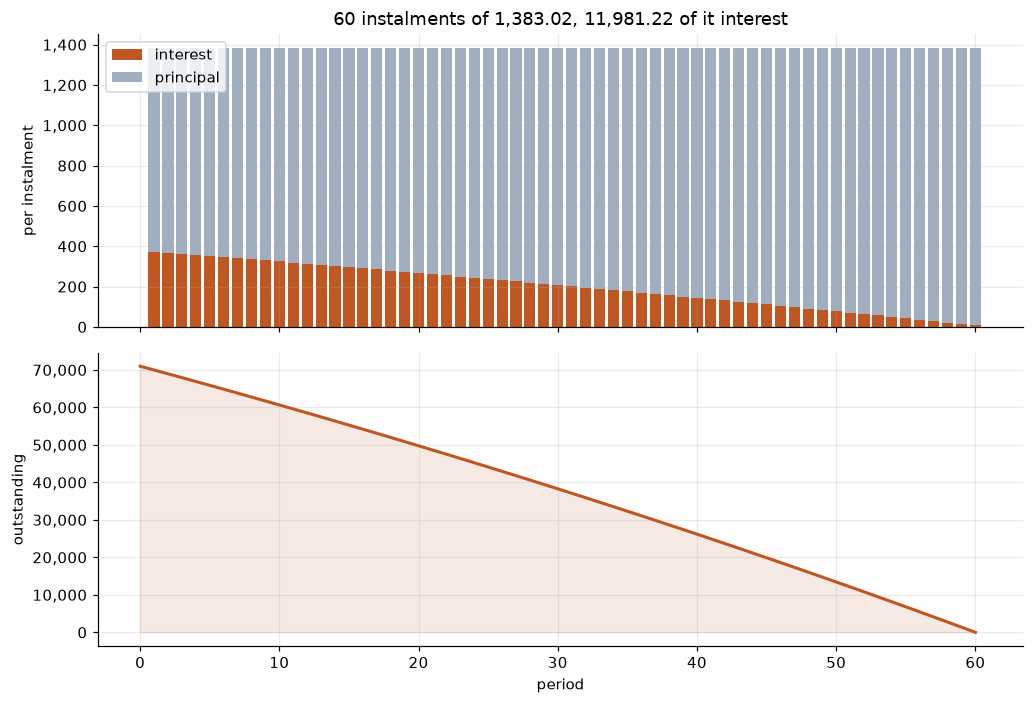

In [6]:
ctx = Context(timeline=timeline, usage=usage)
schedule = loan.schedule(machine.capital_cost, ctx)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(9.5, 6.5), sharex=True)

top.bar(schedule.period, schedule.interest, label="interest", color=BORROWED)
top.bar(
    schedule.period,
    schedule.principal,
    bottom=schedule.interest,
    label="principal",
    color="#a0aec0",
)
top.yaxis.set_major_formatter(MONEY)
top.set_ylabel("per instalment")
top.set_title(
    f"{schedule.period.size} instalments of {schedule.instalment:,.2f}, "
    f"{schedule.total_interest():,.2f} of it interest"
)
top.legend()

balance = np.concatenate(([schedule.opening[0]], schedule.closing))
when = np.concatenate(([schedule.period[0] - 1], schedule.period))
bottom.plot(when, balance, color=BORROWED, linewidth=2)
bottom.fill_between(when, balance, color=BORROWED, alpha=0.12)
bottom.yaxis.set_major_formatter(MONEY)
bottom.set_ylabel("outstanding")
bottom.set_xlabel("period")
plt.tight_layout()
plt.show()

## The answer

`incremental` gives the differential stream between the two, which is the only
honest way to ask what the switch itself is worth.

In [7]:
step = result.incremental("Pay cash", "Borrow at 6.5%")
per_hour = result["Pay cash"].cost_per_unit("hours")

display(
    Markdown(
        f"Paying cash rather than borrowing is worth **{step.npv:,.2f}** in present value.\n\n"
        f"Owning and running the mill costs **{per_hour:,.2f} per machine-hour** "
        f"at {usage.annual('hours'):,.0f} hours a year.\n\n"
        + "\n".join(f"- {note}" for note in result.constraints)
    )
)

Paying cash rather than borrowing is worth **2,485.18** in present value.

Owning and running the mill costs **12.81 per machine-hour** at 1,600 hours a year.

- Borrow at 6.5%: Borrowing at 6.50% against a discount rate of 5.00%: the loan destroys value relative to paying cash.